In [1]:
#First execute this cell go to Runtime and click on Restart Runtime
!pip install --upgrade --no-deps statsmodels
!pip install  StatsForecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


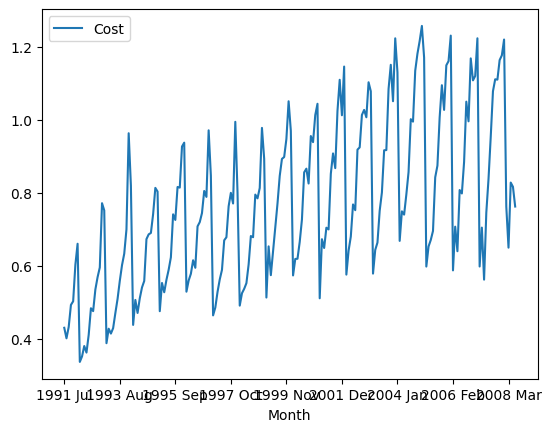

In [2]:
import pandas as pd
from matplotlib import pyplot
ap1=pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/h02.csv')
ap1=ap1.set_index('Month')
ap1.plot()
pyplot.show()


In [3]:
ap1

,Cost
Month,
1991 Jul,0.429795
1991 Aug,0.400906
1991 Sep,0.432159
1991 Oct,0.492543
1991 Nov,0.502369
...,...
2008 Feb,0.761822
2008 Mar,0.649435
2008 Apr,0.827887


Using the above data set

1)Test stationary of the dataset.Write hypothesis. What is your conclusion at 5% siginifance level?

2)Take difference and seasonal difference and test stationay of the dataset.Write hypothesis. What is your conclusion at 5% siginifance level?

3) Plot ACF and PACF of series if series' difference and seasonal difference taken .

4) Based on the plot of ACF and PACF, come up with two SARIMA model and compare their Akaike Information Criterion metric.

5)Split data into train and test. For the test data, use last 12 months observation.

6)Plot test, train and forecast values for the SARIMA model chosen at Q4. Evaluate performance of the model in terms of MAE(mean absulate error), MAPE(mean absulate percentage error) and MSE(Mean squared Error).

7) Using the Statsforecast library, implement the following models: AutoARIMA, AutoETS, HoltWinters,  AutoTheta, and MSTL and plot the forecast of this model .Evaluate the performance of these model model using  MSE (Mean Squared Error).Note that seasonality period is 12.


In [4]:
#Q 1
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
result = adfuller(ap1.iloc[:,0])

# Print results
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -1.6967562070359845
p-value: 0.43278454683042955
Critical Values:
1% : -3.465620397124192
5% : -2.8770397560752436
10% : -2.5750324547306476


ADF Statistic: -5.07040327971582
p-value: 1.607283495966982e-05
Critical Values:
1% : -3.467631519151906
5% : -2.8779183721695567
10% : -2.575501353364474


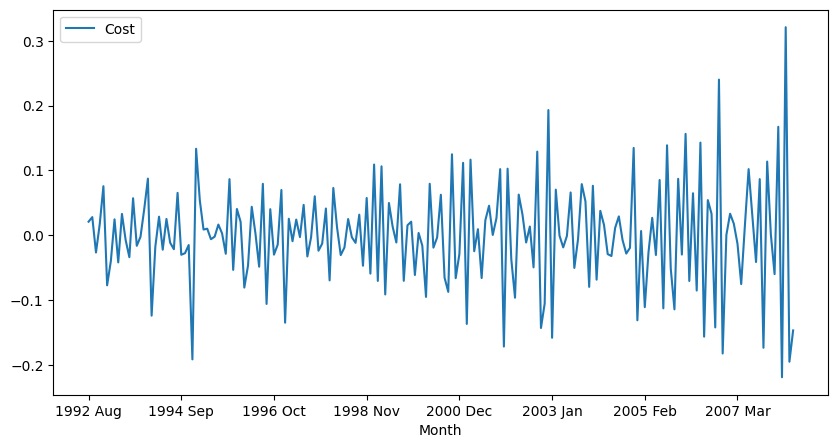

In [5]:
#Q 2
from statsmodels.tsa.stattools import adfuller

# First difference
diff1 = ap1.diff().dropna()

# Seasonal difference (12 months)
seasonal_diff = diff1.diff(12).dropna()

# Plot transformed series
seasonal_diff.plot(figsize=(10,5))

# ADF Test
result = adfuller(seasonal_diff.iloc[:,0])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(key, ":", value)

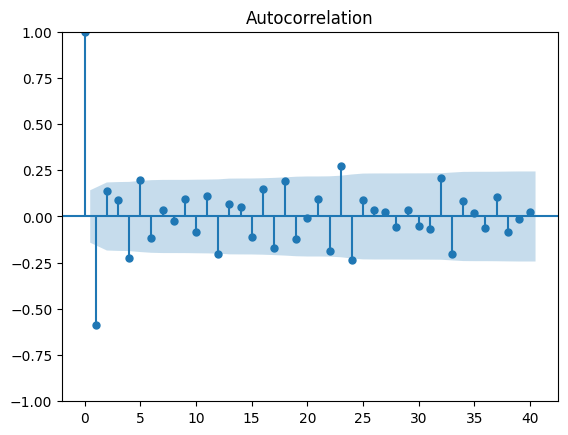

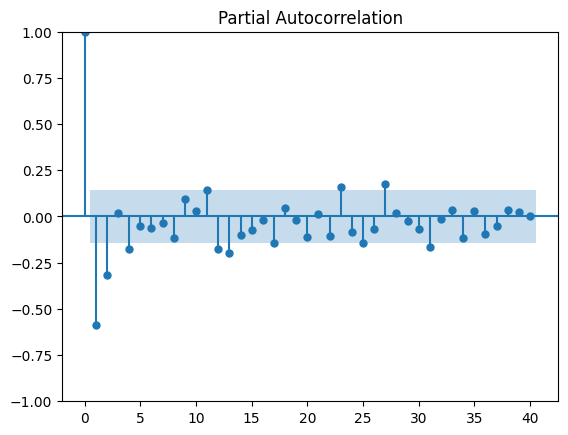

In [6]:
#Q 3
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib import pyplot

# First difference
diff1 = ap1.diff().dropna()

# Seasonal difference (12-month)
seasonal_diff = diff1.diff(12).dropna()

# ACF Plot
plot_acf(seasonal_diff.iloc[:,0], lags=40)

pyplot.show()

# PACF Plot
plot_pacf(seasonal_diff.iloc[:,0], lags=40)

pyplot.show()


In [7]:
#Q 4
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Model 1
model1 = SARIMAX(
    ap1,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result1 = model1.fit()

# Model 2
model2 = SARIMAX(
    ap1,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)

result2 = model2.fit()

# Print AIC values
print("Model 1 AIC:", result1.aic)
print("Model 2 AIC:", result2.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/loc

Model 1 AIC: -554.6784172937761
Model 2 AIC: -552.3288606185369


In [8]:
#Q 5
# Split dataset into train and test

train = ap1.iloc[:-12]
test = ap1.iloc[-12:]

# Print shapes
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

# Display datasets
print("\nTrain Data")
print(train.tail())

print("\nTest Data")
print(test)

Train Shape: (192, 1)
Test Shape: (12, 1)

Train Data
              Cost
Month             
2007 Feb  0.597753
2007 Mar  0.704398
2007 Apr  0.561760
2007 May  0.745258
2007 Jun  0.837934

Test Data
              Cost
Month             
2007 Jul  0.954144
2007 Aug  1.078219
2007 Sep  1.110982
2007 Oct  1.109979
2007 Nov  1.163534
2007 Dec  1.176589
2008 Jan  1.219941
2008 Feb  0.761822
2008 Mar  0.649435
2008 Apr  0.827887
2008 May  0.816255
2008 Jun  0.762137


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


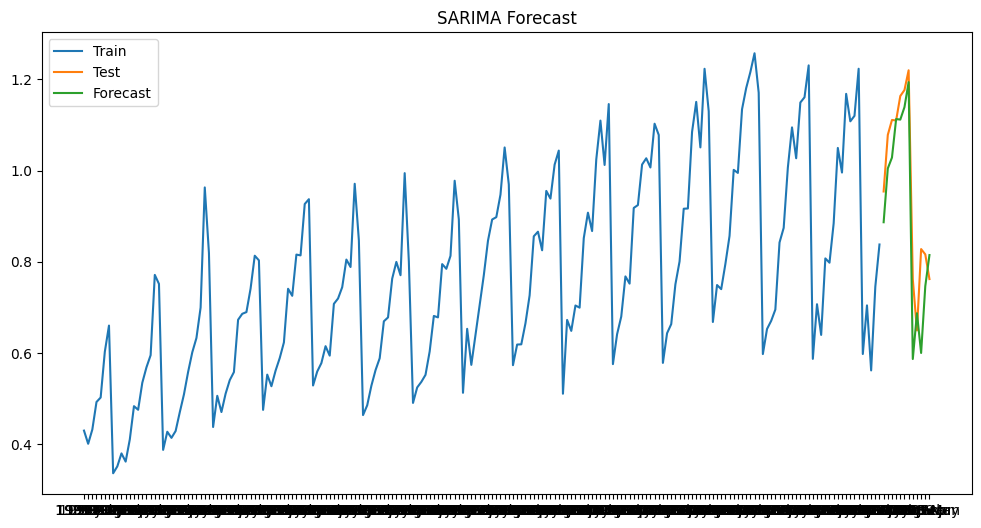

MAE : 0.07538806765537652
MSE : 0.009426443731122518
MAPE: 24.879921946092377


In [9]:
#Q 6
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
from matplotlib import pyplot

# Fit SARIMA model on training data
model = SARIMAX(
    train,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)

result = model.fit()

# Forecast next 12 months
forecast = result.forecast(steps=12)

# Plot train, test and forecast
pyplot.figure(figsize=(12,6))

pyplot.plot(train.index, train, label='Train')
pyplot.plot(test.index, test, label='Test')
pyplot.plot(test.index, forecast, label='Forecast')

pyplot.legend()
pyplot.title("SARIMA Forecast")
pyplot.show()

# Evaluation Metrics
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100

print("MAE :", mae)
print("MSE :", mse)
print("MAPE:", mape)

/tmp/ipykernel_22162/167145559.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['ds'] = pd.date_range(start='1958-01', periods=len(df), freq='M')
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:462: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


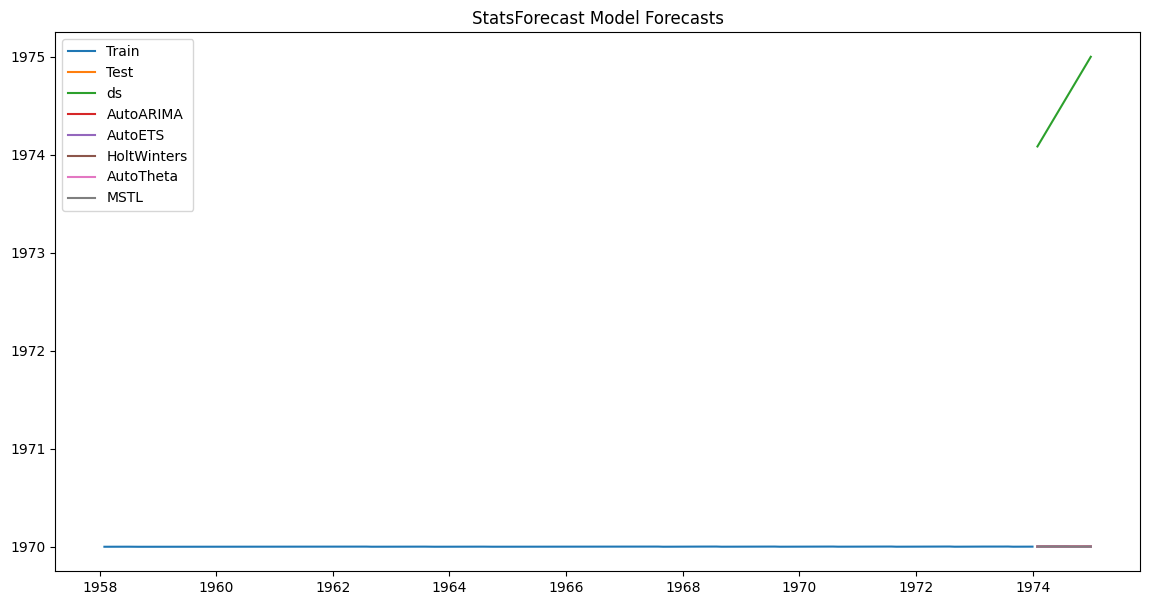

MSE Values

ds : 2.0576778416640001e+34
AutoARIMA : 0.008326675434742747
AutoETS : 0.00723033133678136
HoltWinters : 0.009043982984353787
AutoTheta : 0.007917589771360945
MSTL : 0.007666505528031649


In [10]:
#Q 7
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot

from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA,
    AutoETS,
    HoltWinters,
    AutoTheta,
    MSTL
)

# Prepare dataframe for StatsForecast
df = ap1.reset_index()

# Rename columns
df.columns = ['ds', 'y']

# Convert date column
df['ds'] = pd.date_range(start='1958-01', periods=len(df), freq='M')

# Add unique_id column
df['unique_id'] = 'series1'

# Train-test split
train_df = df.iloc[:-12]
test_df = df.iloc[-12:]

# Define models
models = [
    AutoARIMA(season_length=12),
    AutoETS(season_length=12),
    HoltWinters(season_length=12),
    AutoTheta(season_length=12),
    MSTL(season_length=12)
]

# Fit models
sf = StatsForecast(
    models=models,
    freq='M'
)

sf.fit(train_df)

# Forecast next 12 months
forecasts = sf.predict(h=12)

# Plot forecasts
pyplot.figure(figsize=(14,7))

# Train data
pyplot.plot(train_df['ds'], train_df['y'], label='Train')

# Test data
pyplot.plot(test_df['ds'], test_df['y'], label='Test')

# Forecasts
for col in forecasts.columns[1:]:
    pyplot.plot(test_df['ds'], forecasts[col], label=col)

pyplot.legend()
pyplot.title("StatsForecast Model Forecasts")
pyplot.show()

# Evaluate MSE
print("MSE Values\n")

for col in forecasts.columns[1:]:
    mse = mean_squared_error(test_df['y'], forecasts[col])
    print(col, ":", mse)